In [19]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt


In [20]:
#Como se ve los datos de ACT, que son los de actividades a nivel nacional, pero los datos sacados de SERNATUR, vienen en un 
# excel, de distintas hojas, se busco la hoja de las actividades a nivel comunal y los valores en UF, y se guardo de forma .csv 
# link de acceso: https://drive.google.com/file/d/1oT_dOtQNLex4SrVSCtvOD6iF34971zEQ/view?usp=sharing
#file_id_encuesta = "1oT_dOtQNLex4SrVSCtvOD6iF34971zEQ"
#url = f"https://drive.google.com/uc?id={file_id_encuesta}"
#viajes_ocacionales = pd.read_csv(url, sep=";", encoding="latin1", low_memory=False)
#

## Nota:
# El archivo Viajes-ocasionales-6.csv no se incluye en drive debido a su tamaño.
# Para ejecutar el notebook, debe ubicarse dentro de la carpeta "datos".
viajes_ocacionales = pd.read_csv(r"C:\Users\hmfc_\Documents\cursos mios\Diplomado ciencias\Viajes-ocasionales-6.csv", sep=";", encoding="latin1", low_memory=False)
viajes_ocacionales.head()
#Como es el archivo, que contiene 



,CUT Comuna Origen,Comuna Origen,CUT Provincia Origen,Provincia Origen,CUT Región Origen,Región Origen,CUT Comuna Destino,Comuna Destino,Destino Turístico,CUT Provincia Destino,...,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,1101,Iquique,11,Iquique,1,Tarapacá,1402,Camiña,Camiña,14,...,"33,643461227417","105,965751409531","99,9849243164062","14,9766898155212","25,7534079551697","25,3820378780365","117,386157989502","145,944531440735","44,3386154174805","64,348644733429"
1,1101,Iquique,11,Iquique,1,Tarapacá,1403,Colchane,Colchane - P.N. Volcán Isluga,14,...,"110,10587310791","139,269273281097","99,9849243164062","68,8927731513977","168,827896595001","157,932680130005","262,7214012146","131,911403417587","160,727480888367","436,451677322388"
2,1101,Iquique,11,Iquique,1,Tarapacá,1404,Huara,Resto región Tarapacá,14,...,"1064,35677337646","2086,01150631905","1521,64556694031","973,484838008881","1573,81937503815","6449,85784745216","1900,53779602051","1299,46765494347","1144,49051046371","1421,26571846008"
3,1101,Iquique,11,Iquique,1,Tarapacá,1405,Pica,Pica,14,...,"932,841424942017","1653,06572198868","1568,51350021362","934,545444488525","1485,11319208145","1613,16951847076","2495,8533115387","1403,31280231476","1629,44411659241","2039,57226133347"
4,1101,Iquique,11,Iquique,1,Tarapacá,2101,Antofagasta,Antofagasta,21,...,"899,1979637146","1068,74029278755","1849,72109985352","748,834490776062","1115,98101139069","1644,19200921059","1771,97200393677","1465,05856561661","1199,91377973557","1631,09825563431"


In [21]:
#Cuantas filas y columna contiene
viajes_ocacionales.shape

(649393, 26)

In [22]:
#Cual es la informacion, tipo de dato, entre otras cosas de la columna
viajes_ocacionales.info()

<class 'pandas.DataFrame'>
RangeIndex: 649393 entries, 0 to 649392
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   CUT Comuna Origen      649393 non-null  int64
 1   Comuna Origen          649393 non-null  str  
 2   CUT Provincia Origen   649393 non-null  int64
 3   Provincia Origen       649393 non-null  str  
 4   CUT Región Origen      649393 non-null  int64
 5   Región Origen          649393 non-null  str  
 6   CUT Comuna Destino     649393 non-null  int64
 7   Comuna Destino         649393 non-null  str  
 8   Destino Turístico      649393 non-null  str  
 9   CUT Provincia Destino  649393 non-null  int64
 10  Provincia Destino      649393 non-null  str  
 11  CUT Región Destino     649393 non-null  int64
 12  Región Destino         649393 non-null  str  
 13  Anio                   649393 non-null  int64
 14  Enero                  648801 non-null  str  
 15  Febrero                64913

In [23]:
#Que columnas tiene 
viajes_ocacionales.columns

Index(['CUT Comuna Origen', 'Comuna Origen', 'CUT Provincia Origen',
       'Provincia Origen', 'CUT Región Origen', 'Región Origen',
       'CUT Comuna Destino', 'Comuna Destino', 'Destino Turístico',
       'CUT Provincia Destino', 'Provincia Destino', 'CUT Región Destino',
       'Región Destino', 'Anio', 'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo',
       'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre',
       'Diciembre'],
      dtype='str')

In [25]:
# Valores faltantes
viajes_ocacionales.isna().sum().sort_values(ascending=False)

Diciembre                821
Enero                    592
Noviembre                405
Julio                    387
Septiembre               359
Junio                    323
Marzo                    268
Febrero                  260
Agosto                   252
Octubre                  244
Abril                    178
Mayo                     162
CUT Provincia Destino      0
Destino Turístico          0
Región Origen              0
CUT Región Origen          0
Provincia Origen           0
CUT Provincia Origen       0
Comuna Origen              0
CUT Comuna Origen          0
Comuna Destino             0
CUT Comuna Destino         0
Provincia Destino          0
CUT Región Destino         0
Región Destino             0
Anio                       0
dtype: int64

In [29]:
# Registros duplicados
viajes_ocacionales.duplicated().sum()


np.int64(0)

In [35]:
# Antes de ver que se va a hacer con los valores faltantes, se va arreglar la tabla, a los datos que son los viajes
#ocasionales de mayo y solo del año 2025, y luego eliminar los valores faltantes.
viajes_mayo_años = viajes_ocacionales[['Comuna Origen', 'Comuna Destino', 'Anio', 'Mayo']]
viajes_mayo_años.head()


,Comuna Origen,Comuna Destino,Anio,Mayo
0,Iquique,Camiña,2019,"99,9849243164062"
1,Iquique,Colchane,2019,"99,9849243164062"
2,Iquique,Huara,2019,"1521,64556694031"
3,Iquique,Pica,2019,"1568,51350021362"
4,Iquique,Antofagasta,2019,"1849,72109985352"


In [ ]:
#Ver si hay algun dato del 2025
viajes_mayo_años["Anio"].unique()
#Filtrar los datos del 2025
viajes_2025 = viajes_mayo_años[viajes_mayo_años["Anio"] == 2025]
# viajes_2025.shape

(92540, 4)

In [ ]:
#filtrar los datos de comuna destino=San Fernando. Trabjar con esta tabla llamada viajes_sf
viajes_sf = viajes_2025[viajes_2025["Comuna Destino"] == "San Fernando"]
viajes_sf.head()

,Comuna Origen,Comuna Destino,Anio,Mayo
556950,Iquique,San Fernando,2025,"27,4117892359887"
557283,Alto Hospicio,San Fernando,2025,"3,66403275676709"
557593,Pozo Almonte,San Fernando,2025,0
558091,Pica,San Fernando,2025,0
558412,Antofagasta,San Fernando,2025,"43,7050665270014"


In [ ]:
#Ver si la nueva tabla tiene datos faltantes.
viajes_sf.isna().sum().sort_values(ascending=False)

Comuna Origen     0
Comuna Destino    0
Anio              0
Mayo              0
dtype: int64

In [ ]:
# Como mayo esta como letra, dejar como numero, y ver su tipo de formato como quedo 
viajes_sf["Mayo"] = (viajes_sf["Mayo"].astype(str).str.replace(",", ".", regex=False).astype(float))
viajes_sf.info()


<class 'pandas.DataFrame'>
Index: 297 entries, 556950 to 649194
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Comuna Origen   297 non-null    str    
 1   Comuna Destino  297 non-null    str    
 2   Anio            297 non-null    int64  
 3   Mayo            297 non-null    float64
dtypes: float64(1), int64(1), str(2)
memory usage: 11.6 KB


In [ ]:
#Calculo de las cariables de la tendencia central 
print("=== Tendencia Central ===")
print("Media:", viajes_sf["Mayo"].mean())
print("Mediana:", viajes_sf["Mayo"].median())
print("Moda:", viajes_sf["Mayo"].mode())


=== Tendencia Central ===
Media: 55.80552292856835
Mediana: 3.68421187733503
Moda: 0    0.0
Name: Mayo, dtype: float64


Con los datos que nos entrega la tendencia central, en promedio de viajes ocasionales de una comuna a san fernando es de 55,8055 viajes en el año 2025 en el mes de mayo, la mediana es de 3,6842 viajes ocasionales en el mes de mayo en el año 2025, y la moda es 0, esto nos indica que varias personas de comunas distintas de origen no viajan a San Fernando en el mes de mayo en el año 2025. Estos datos indican  que la mayoría de las comunas generan pocos viajes y que existen algunas comunas que concentran un volumen muy elevado de desplazamientos hacia San Fernando, elevando el promedio general.

In [ ]:
# Caluclo de la dispersion (desviación, varianza, y rango)
print("\n=== Dispersión ===")
print("Desviación estándar:", viajes_sf["Mayo"].std())
print("Varianza:", viajes_sf["Mayo"].var())
print("Rango:",viajes_sf["Mayo"].max()-viajes_sf["Mayo"].min())


=== Dispersión ===
Desviación estándar: 156.21920599069267
Varianza: 24404.44032036247
Rango: 1558.04747894519




La desviación estándar es de 156,2192 viajes que nos indica que hay una alta variabilidad entre las comunas de origen. Y este dato nos comunica que el comportamiento de los viajes no es homogéneo, existiendo una diferencia importante entre comunas con baja generación de viajes y otras que aportan un volumen considerablemente mayor.

El rango de 1.558 viajes muestra una gran distancia entre la comuna con menor flujo y la comuna con mayor flujo hacia San Fernando, reforzando la existencia de una distribución muy desigual.



In [ ]:
#Calculo de asimetria y curtosis
print("Asimetría:", viajes_sf["Mayo"].skew())
print("Curtosis:", viajes_sf["Mayo"].kurt())


Asimetría: 5.654293223671068
Curtosis: 41.26560729544804


La asimetría es positiva, ya que es 5,65, esto indica una distribución fuertemente sesgada hacia la derecha. Esto significa que la mayoría de las comunas presentan bajos niveles de viajes hacia San Fernando, mientras que unas pocas comunas concentran una cantidad excepcionalmente alta de desplazamientos.

La curtosis que fue de 41,27, es extremadamente elevada, lo que evidencia la presencia de valores atípicos o extremos. En términos prácticos, existen comunas que generan un volumen de viajes muy superior al comportamiento general observado en el conjunto de datos.

In [69]:
viajes_sf.describe()

,Anio,Mayo
count,297.0,297.000000
mean,2025.0,55.805523
std,0.0,156.219206
min,2025.0,0.000000
25%,2025.0,0.000000
50%,2025.0,3.684212
75%,2025.0,29.923011
max,2025.0,1558.047479


El 25% de las comunas registra cero viajes hacia San Fernando durante mayo de 2025. Además, el 50% de las comunas genera menos de 
3,68 viajes y el 75% menos de 29,92 viajes. Esto confirma que la mayor parte de las comunas presenta flujos bajos de desplazamiento, mientras que un grupo reducido concentra la mayor demanda de viajes.

Estos datos, de los viajes ocasionales, no tienen factor de expansion, porque son todos los datos que registran SERNATUR en cada mes y años. Entonces estos datos, nos va para crear el factor de expansion para la encuesta de la vendimia de San Fernando y saber cuantas personas asistieron en los tres dias a la fiesta de la vendimia. 

De esta tabla se tiene dos variables, una variable es categorica que es la Comuna Origen, y la variable cuantitativa es Mayo. DE estas varibales, se va querer observar como se corresponde y compararlo para este avance con los datos de origen de los encuestados y con esto.

In [91]:
top_comunas = (viajes_sf.groupby("Comuna Origen")["Mayo"].sum().sort_values(ascending=False))

top_comunas.head(20)


Comuna Origen
Rancagua            1558.047479
Curicó              1196.985209
Puente Alto          804.867577
Santiago             703.224437
Talca                663.485308
Maipú                627.867506
San Bernardo         479.773134
Las Condes           461.725542
La Florida           437.268559
Quilicura            375.014466
Machalí              351.927082
Pudahuel             344.373360
Peñalolén            332.581480
Ñuñoa                328.010129
Estación Central     266.850330
Viña del Mar         260.291363
San Miguel           240.746875
Providencia          229.974534
Colina               229.847324
Chillán              218.789960
Name: Mayo, dtype: float64

In [92]:
viajes_sf["Nivel Viajes"] = pd.cut(viajes_sf["Mayo"], bins=[-1, 0, 10, 50, 10000],  labels=["Sin viajes","Bajo","Medio","Alto"])

pd.crosstab(viajes_sf["Comuna Destino"],viajes_sf["Nivel Viajes"])

Nivel Viajes,Sin viajes,Bajo,Medio,Alto
Comuna Destino,,,,
San Fernando,110,83,44,60


 la tabla. Y tambien cone esto nos confirma que la ditribución es homogénea entre las comunas de origen. Algunas comunas concentran una proporción significativamente mayor de viajes hacia San Fernando durante mayo de 2025, mientras que gran parte de las comunas presenta flujos bajos o nulos. Y se descubre que  de 110 comunas las comunas no han ido a San fernando en mayo del 2025.

En esta, como es una unica variable cuantitativa principal (cantidad estimada de viajes en mayo de 2025), no resulta pertinente calcular correlaciones de Pearson o Spearman entre variables numéricas. El análisis bivariado se desarrolla mediante comparaciones entre comunas de origen y volumen de viajes.

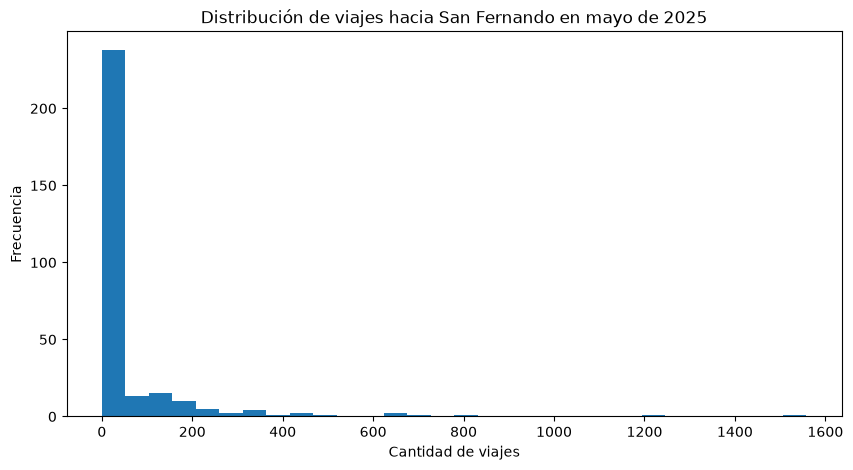

In [93]:

plt.figure(figsize=(10,5))

plt.hist(viajes_sf["Mayo"], bins=30)
plt.title("Distribución de viajes hacia San Fernando en mayo de 2025")
plt.xlabel("Cantidad de viajes")
plt.ylabel("Frecuencia")

plt.show()

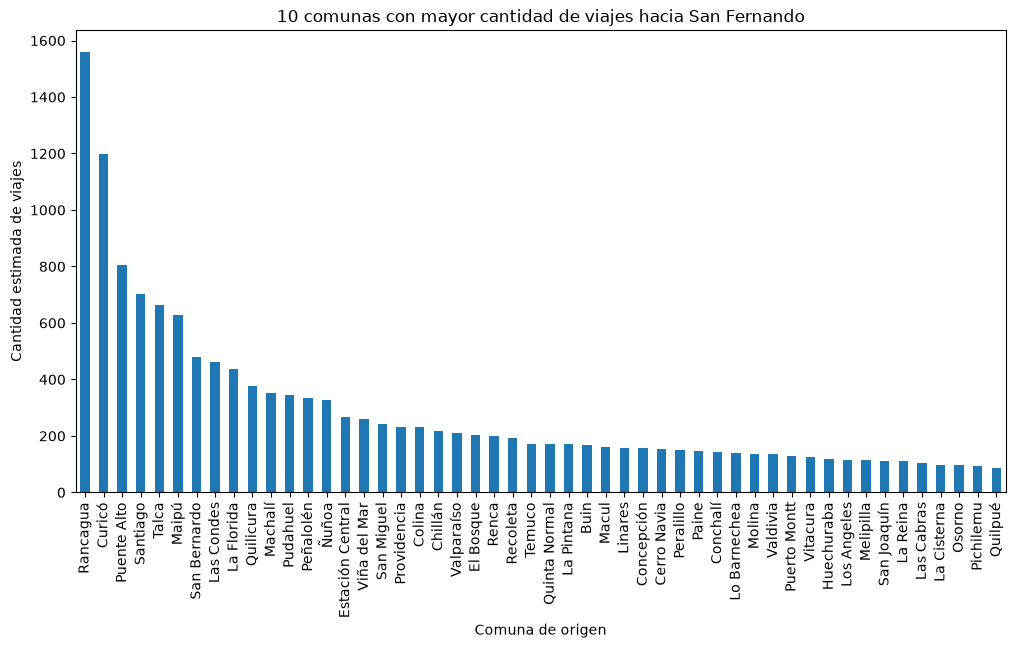

In [96]:
top_10 = (viajes_sf.groupby("Comuna Origen")["Mayo"].sum().sort_values(ascending=False).head(50))
plt.figure(figsize=(12,6))

top_10.plot(kind="bar")

plt.title("10 comunas con mayor cantidad de viajes hacia San Fernando")
plt.xlabel("Comuna de origen")
plt.ylabel("Cantidad estimada de viajes")

plt.show()